# BP Strength Classification — Feature Engineering

## Context and goal

The library contains ~101.000 sequences that differ in four elements: the BP 
heptamer, the PYT tract, the decoy BP, and the anchor sequence. To model how 
each element contributes to A complex assembly, each one needs to be represented 
as a numeric or categorical variable.

BP strength was not directly available as a label — it had to be constructed.
This notebook documents how the `BP_class` feature (Strong / Intermediate / Weak) 
was built from the experimental data.

---

## Why not just use raw read counts?

Read counts reflect the combined effect of all variables at once: BP strength, 
PYT strength, decoy competition, drug concentration, and experimental noise. 
Using them directly as a proxy for BP strength would confound everything together.

The cleaner approach is to isolate a condition where BP is the dominant variable 
and use that as the reference.

---

## Reference condition: No Decoy + Strong PYT (control)

In the no-decoy, strong PYT, no-drug condition, the other variables are either 
fixed or absent. Under this assumption, the normalized read count for a given BP 
sequence reflects mostly its intrinsic capability to support A complex assembly — 
i.e., its strength.

This is the biological assumption the classification is built on. It is an 
approximation, but a reasonable one for a first model.

---

## Validation with SVM-BPfinder

Before committing to the empirical distribution, we checked whether it actually 
captures BP strength by comparing it against an independent computational score.

SVM-BPfinder scans intronic sequences and scores BP candidates based on sequence 
context, pyrimidine content, and polypyrimidine tract features. It returns a 
single SVM score per candidate, which is a well-established proxy for BP strength.

**Steps:**
- Sequences were preprocessed: T7 promoter removed, trimmed at the last CAG 
  (3′ splice site). All ~52,807 sequences passed QC.
- SVM-BPfinder was run on terminal:  
  `python3 svm_bpfinder.py -i test_sequence.fasta -s Hsap -l 100 -d 10`  
  returning ~141,000 candidate BPs.
- Only candidates whose predicted 9-mer contained the known experimental BP 
  heptamer were kept (~20,826 sequences retained).
- For each unique BP (~1,700 out of ~4,000), mean SVM score and empirical read 
  fraction were computed and compared.

**Result:** Pearson and Spearman correlations between SVM score and empirical 
read fraction were significant. The correlation held across all decoy conditions 
and drug concentrations. One anomalous cluster (high fraction + high residual) 
was removed before the final stats.

This confirms that the empirical distribution in the reference condition is a 
valid proxy for BP strength, and can be used to label all sequences — including 
those not covered by SVM-BPfinder (~7.5% of unique BPs remain `Unknown`).

---

## Classification

BP sequences were ranked by mean normalized reads in the reference condition 
(no-decoy, strong PYT, control). Rank-based quartile cuts were applied:

| Class        | Rank position       |
|--------------|---------------------|
| Strong       | Top 25%             |
| Intermediate | 25% – 75%           |
| Weak         | Bottom 25%          |

The resulting labels were assigned to the full `data_filtered` dataframe via 
`np.select`, producing the `BP_class` column used in downstream modeling.

In [ ]:
# Standard libraries used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import itertools
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math
import os
import scipy.stats as stats
# --------------------------------------------------------------------------
# PARAMETER — PATH_DATASET
# --------------------------------------------------------------------------

PATH_RAW_DATASET = r"C:\Users\marco\Desktop\Tesi\.LabWork\Data\Data from Suzanne\fitness_calc_PB_H3B.xlsx"
PATH_LOG_READS_NORMALIZED = r"C:/Users/marco/Desktop/Tesi/.LabWork/Results/log_reads_norm.csv"
PATH_LFC = "C:/Users/marco/Desktop/Tesi/.LabWork/Results/lfc_results.csv"
# We load the raw file with no changes.
# data_raw will never be modified — it stays as the original reference.
data_raw = pd.read_excel(PATH_RAW_DATASET)
data_reads_norm = pd.read_csv(PATH_LOG_READS_NORMALIZED)
data_lfc = pd.read_csv(PATH_LFC)

data_reads_norm.columns = data_reads_norm.columns.str.replace(
    "output_", "norm_reads_", regex=False
)

data_lfc.drop(columns=["DECOY", "PYT", "ANCHOR"], inplace=True)

# --------------------------------------------------------------------------
# Data Merging ( unify the datasets)
# --------------------------------------------------------------------------
df_CLR_norm = pd.merge(data_reads_norm, data_lfc, on="seq_id")
df_CLR_norm['seq_id'] = df_CLR_norm['seq_id'].astype(int)
data = pd.merge(data_raw, df_CLR_norm, on="seq_id")
# --------------------------------------------------------------------------
# Data Filtering
# --------------------------------------------------------------------------

MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

data_filtered = data[mask_ok].copy().reset_index(drop=True)
data_filtered['ANCHOR'] = data_filtered['ANCHOR'].astype(str)

# --------------------------------------------------------------------------
# CONSTANT definition
# --------------------------------------------------------------------------
DRUG_CONCENTRATIONS_raw = [1e-11, 1e-10, 2e-10, 4e-10, 1e-09]
def scale_drug_concentration(drug_linear, 
                             min_real=1e-11, 
                             max_real=1e-9, 
                             min_scaled=0., 
                             max_scaled=100.0):
    """
    Scala la concentrazione lineare del farmaco in un range lineare personalizzato (es. 1-100)
    passando prima per lo spazio logaritmico, per preservare la sensibilità alle basse dosi.
    """
    # 1. Passaggio allo spazio logaritmico (esponenti)
    log_drug = np.log10(drug_linear)
    log_min = np.log10(min_real)  # -11
    log_max = np.log10(max_real)  # -9
    
    # 2. Traslazione e riscalamento lineare dell'esponente nel nuovo range [min_scaled, max_scaled]
    drug_scaled = min_scaled + (log_drug - log_min) * (max_scaled - min_scaled) / (log_max - log_min)
    
    return drug_scaled

DRUG_CONCENTRATIONS = scale_drug_concentration(DRUG_CONCENTRATIONS_raw)


variables = ['ANCHOR', 'DECOY', 'PYT']
lfc = [col for col in data_filtered.columns if 'lfc' in col]
normalized = [col for col in data_filtered.columns if 'norm_reads' in col]

focus_cols = ['seq_id', *variables, *lfc, *normalized]
df_lfc = data_filtered.loc[:, focus_cols]




unique_values = [df_lfc[col].dropna().unique() for col in variables]
combinations_names = list(itertools.product(*unique_values))

stratified_data =  {}
for key_classes, subset in df_lfc.groupby(variables):
    stratified_data[key_classes] = subset.drop(
        columns = variables
    )

### Create useful functions

In [2]:
def filter_sequence(sequence: str, to_find: str) -> str:
    """Optimizes the input sequence for the SVM finder by removing the final

    section that follows the specified sub-string (e.g., 'CAG').

    Parameters:
        - sequence: str, the string to be cut
        - to_find: str, the sub-string to locate

    Returns:
        - str: The subsetted string, including the 'to_find' sequence at the
        end.
    Raise:
        - ValueError if the to_find string isn't in the sequence
    """
    # Find the index of the last occurrence (searching from right to left)
    idx = sequence.rfind(to_find)

    # If the sub-string is not found, rfind returns -1.
    if idx == -1:
    # In this case, we return the original sequence.
        raise ValueError(f"The string {to_find} is not in {sequence}.")

    # Slice the string to keep everything from the beginning
    # up to the end of 'to_find' (inclusive)
    return sequence[: idx + len(to_find)]

def BP_extractor(data):
    final_str = 'CAG'
    linker = 'GCG'
    strong_pyt = 'UUUUUCUUUUCUUUU'.replace('U', 'T')
    
    suffix_len = len(linker + strong_pyt + final_str)  # 21nt
    
    return data['full_seq'].apply(lambda seq: seq[-(suffix_len+7):-suffix_len])


def translator_to_DNA(tuples):
    nuove_tuple = []
    for nome, seq in tuples:
        # Trasforma in maiuscolo e sostituisce la U con la T
        seq_dna = seq.upper().replace('U', 'T')
        # Salva la coppia nella nuova lista
        nuove_tuple.append((nome, seq_dna))
    return nuove_tuple

In [149]:
pattern = 'CAG'

data_raw['full_seq'] = data_raw['full_seq'].apply(
    lambda seq: filter_sequence(seq, pattern)
)

data_raw['BP_extracted'] = BP_extractor(data_raw)

### Focus only to the Strong PYT condition

In [3]:
dna = pd.DataFrame(data_filtered).copy()
dna = dna.loc[ dna['PYT'] == 'Strong', :].reset_index(drop=True)

### Manipulate data

In [4]:
dna["seq_feature"] = (
    dna["DECOY"].astype(str)
    + '__'
    + "PYT "
    + dna["PYT"].astype(str)
    + '__'
    + "ANCHOR "
    + dna["ANCHOR"].astype(str)
    + '__'
    + 'Seq_id: ' 
    + dna['seq_id'].astype(str)
)

### Sequence inspection

In [5]:
ref = 'cgTAATACGACTCACTATAGGGcUACUACGUCAGCUCGUCUCGAGGGUACUAACgcgUUUUUCUUUUCUUUUCAGGGUACGCAU'

tuples = [
    ('t7', 'cgTAATACGACTCACTATAGGGc'),
    ('decoy', 'UACUAC'),
    ('ANCHOR_1', 'GGGUUUCCUGAAGCUUUCG'),
    ('ANCHOR_2', 'GUCAGCUCGUCUCGAGGG'),
    ('branch_point', 'UACUAAC'),
    ('nt_linker', 'gcg'),
    ('strong_PYT', 'UUUUUCUUUUCUUUU'),
    ('weak_PYT', 'UUgaCUUgUUgaCCU'),
    ('filtered_junction', 'CAG')
]

tuples = translator_to_DNA(tuples)

lunghezze = dna['full_seq'].str.len()

if lunghezze.nunique() == 1:
    print(f"Sì, tutte le stringhe hanno la stessa lunghezza ({lunghezze.iloc[0]} nucleotidi).")
else:
    print("No, ci sono stringhe con lunghezze diverse.")
    print(lunghezze.nunique())


print()
for name, seq in tuples:
    print(f"The length of {name} is: {len(seq)}")
print()
for name, seq in tuples:
    check = dna['full_seq'].str.contains(seq, case=False, na=False).sum() / len(dna['full_seq'])
    print(f" {round((check*100), 0)}% of sequences with the feature: {name}")

No, ci sono stringhe con lunghezze diverse.
2

The length of t7 is: 23
The length of decoy is: 6
The length of ANCHOR_1 is: 19
The length of ANCHOR_2 is: 18
The length of branch_point is: 7
The length of nt_linker is: 3
The length of strong_PYT is: 15
The length of weak_PYT is: 15
The length of filtered_junction is: 3

 100.0% of sequences with the feature: t7
 14.0% of sequences with the feature: decoy
 51.0% of sequences with the feature: ANCHOR_1
 49.0% of sequences with the feature: ANCHOR_2
 0.0% of sequences with the feature: branch_point
 100.0% of sequences with the feature: nt_linker
 100.0% of sequences with the feature: strong_PYT
 0.0% of sequences with the feature: weak_PYT
 100.0% of sequences with the feature: filtered_junction


### Function Tester

### Filter the dataset

In [6]:
pattern = 'CAG'

dna['full_seq'] = dna['full_seq'].apply(
    lambda seq: filter_sequence(seq, pattern)
)

dna['BP_extracted'] = BP_extractor(dna)

## Check for the right sequences

### T7

In [7]:
def all_seq_starst_with_t7(data):

    def is_t7(seq):
        reference = 'cgTAATACGACTCACTATAGGGc'.upper()
        if seq.startswith(reference):
            return True
    check = data['full_seq'].apply(is_t7).sum() / len(data['full_seq'])
    if np.isclose(check, 1.0):
        return True
    else:
        return False

### Decoy

In [8]:
def best_decoy_check(data):
    t7_reference = 'cgTAATACGACTCACTATAGGGc'.upper()
    best_decoy_rna = 'UACUAC'
    best_decoy_dna = translator_to_DNA([('a', best_decoy_rna)])[0][1]
    best_start = t7_reference + best_decoy_dna

    
    obs = data['full_seq'].apply(lambda x: x.startswith(best_start)).sum() 
    if np.isclose(obs, len(data.loc[data['DECOY'] == 'Decoy 1'])):
        print(True)
    else:
        print(False)
    
best_decoy_check(dna)

True


In [9]:
t7_reference = 'cgTAATACGACTCACTATAGGGc'.upper()
best_decoy_rna = 'UACUAC'
best_decoy_dna = translator_to_DNA([('a', best_decoy_rna)])[0][1]
best_start = t7_reference + best_decoy_dna

### Brench Point

In [10]:
def bp_check(data):
    final_str = 'CAG'
    linker = 'GCG'
    strong_pyt = 'UUUUUCUUUUCUUUU'.replace('U', 'T')
    
    length = len(linker + strong_pyt + final_str) + 1
    x = data['full_seq'].copy()
    x_tagliato = [seq[:-length] for seq in x]
    print(f"{((np.array([seq.endswith('A') for seq in x_tagliato]).sum()) / len(data['full_seq']))* 100}% of bp seq has A after linker + N")
bp_check(dna)

100.0% of bp seq has A after linker + N


### pyt + linker

In [11]:
strong_pyt = 'UUUUUCUUUUCUUUU'.replace('U', 'T')
def pyt_check(data):
    final_str = 'CAG'
    linker = 'GCG'
    strong_pyt = 'UUUUUCUUUUCUUUU'.replace('U', 'T')
    # .str.endswith() controlla se la stringa finisce esattamente con quella sequenza

    return data.str.endswith(linker + strong_pyt + final_str)

# Chiamata sulla colonna specifica del DataFrame
pyt_check(dna['full_seq']).all()

np.True_

In [12]:
seq = dna.loc[:, 'full_seq']
x = [s[len(t7_reference):] for s in seq]
decoys = pd.DataFrame([s[:6] for s in x])
decoy_known = 'UACUAC'.replace('U','T')
decoy_known in decoys[0].unique()
decoys[0].unique()

<StringArray>
['GTCGTC', 'TACTAC', 'TACTAG', 'TACTCA', 'TACTCG', 'TAGTAC', 'TAGTCG']
Length: 7, dtype: str

### iNTRON EXON JUNCT

In [13]:
def intron_exon_check(data):
    intron_exon_junc = 'CAG'
    # .str.endswith() controlla se la stringa finisce esattamente con quella sequenza
    return data.str.endswith(intron_exon_junc)

# Chiamata sulla colonna specifica del DataFrame
intron_exon_check(dna['full_seq']).all()


np.True_

In [14]:
t7_reference
dna['full_seq'] = [seq[len(t7_reference):] for seq in dna['full_seq']]

### Create the fasta file

In [15]:
col_id = "seq_feature"
col_seq = "full_seq"

file_name = "test_sequence_Strong_PYT.fasta"

target_folder = r"C:\Users\marco\Desktop\Tesi\.LabWork\Code\3_SVMfinder\SVM-BPfinder-3M"
full_path = os.path.join(target_folder, file_name)

with open(full_path, "w") as fasta_file:
    for row in dna.itertuples(index=False):
        header = getattr(row, col_id)
        sequence = getattr(row, col_seq)
        
        fasta_file.write(f">{header}\n{sequence}\n")

print(f"FASTA file directly created in: {full_path}")
print(f"The data have: {dna.shape[0]} sequences.\nExpected {dna.shape[0] * 2} rows in the FASTA file.")
with open(r"C:\Users\marco\Desktop\Tesi\.LabWork\Code\3_SVMfinder\SVM-BPfinder-3M\test_sequence_Strong_PYT.fasta", "r") as f:
    print(f"Found {sum(1 for riga in f)} in the FATSTA file!")


FASTA file directly created in: C:\Users\marco\Desktop\Tesi\.LabWork\Code\3_SVMfinder\SVM-BPfinder-3M\test_sequence_Strong_PYT.fasta
The data have: 52807 sequences.
Expected 105614 rows in the FASTA file.
Found 105614 in the FATSTA file!


### !!!Simulation Runned on terminal (code: python3 svm_bpfinder.py -i test_sequence.fasta -s Hsap -l 100 -d 10 > BP_results_Strong_PYT.txt)!!!

## Raw result

In [16]:
PATH = r"C:\Users\marco\Desktop\Tesi\.LabWork\Code\3_SVMfinder\SVM-BPfinder-3M\BP_results_Strong_PYT.txt"

df = pd.read_csv(PATH, sep="\t")
res = df.copy()
res['bp_seq']= res['bp_seq'].apply(
    lambda s: s.upper()
) 
res['seq_id_num'] = res['seq_id'].str.extract(r'Seq_id:\s*(\d+)').astype(int)

print(f"SVMfinder hase predicted: {len(dna['BP_extracted'][0])} potential BP")

SVMfinder hase predicted: 7 potential BP


## Filtering 1: Mantain predicted sequences that have BP of the experimental Design

Voglio andare a filtrare solo i barch point che mi interessano no? Perche per ora posso avere: Decoy - anchor - oyt - BP_real come predicted bp

In [18]:
# Right BP extracted
dna['BP_extracted'] = BP_extractor(dna)

check = dna.loc[:, ['BP_extracted', 'seq_id', 'norm_reads_Ctrl']]
to_check = res.loc[:, ['bp_seq', 'seq_id_num', 'svm_scr']]

# Merge on seq_id == seq_id_num
merged = to_check.merge(
    check,
    left_on='seq_id_num',
    right_on='seq_id',
    how='left'
)

# Check: 7-mer reale è sottostringa del 9-mer predetto
bp_match = merged.apply(
    lambda row: isinstance(row['BP_extracted'], str) and row['BP_extracted'] in row['bp_seq'],
    axis=1
)

# Filtra res (non dna) tenendo solo i BP predetti che matchano quelli reali
res_filtered = merged[bp_match]
print(f"Retained: {len(res_filtered)} / {len(res)}")
print(f"Number of unique BP: {res_filtered['bp_seq'].nunique()}")

Retained: 20826 / 141006
Number of unique BP: 1744


## Obs: Only 20.826 sequences are computed (out of 50.000)

# CHOICE: Given that I obtained only 20.000 sequences with real BP and I have 4000 BP sequences varing for other factors, I can look at the mean/median value of the score for each UNIQUE BP (1700 out of 4000) and use that to predict the Strenght. If there are unique BP values not in the 20.000 sequences I'll assign them to the minimum 

# Observation:

# Goal here is to understand the BP influence on the Spliceosome Assemply. Not the BP_strenght per se. 

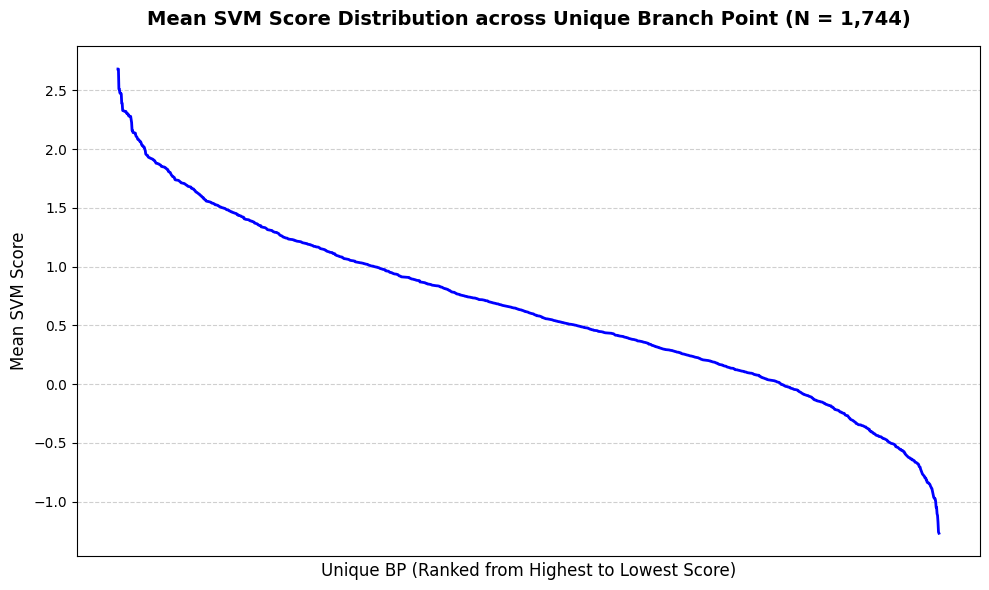

In [19]:
# 1. Calculate the mean svm_scr for each unique bp_seq and sort the results
# Sorting is essential to clearly visualize the distribution and the score gradient
distribution = (
    res_filtered.groupby("bp_seq")["svm_scr"].mean().sort_values(ascending=False)
)

# Dynamically count the number of unique sequences calculated
num_sequences = len(distribution)

# 2. Create the distribution plot
plt.figure(figsize=(10, 6))
plt.plot(distribution.values, marker="", linestyle="-", color="b", linewidth=2)

# 3. Configure the plot layout (hiding X-axis labels for readability)
# The unique sequence count is embedded directly into the title string
plt.title(f"Mean SVM Score Distribution across Unique Branch Point (N = {num_sequences:,})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Unique BP (Ranked from Highest to Lowest Score)", fontsize=12)
plt.ylabel("Mean SVM Score", fontsize=12)
plt.xticks([])  # Completely removes the sequence names from the X-axis
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


Total Unique Categories Evaluated: 3,937
---
Calculated Quartiles for Read Fractions relative to the Total Sum:
First Quartile  (Q1 - 25th percentile): 0.000123
Second Quartile (Q2 - Median):          0.000239
Third Quartile  (Q3 - 75th percentile): 0.0004
---


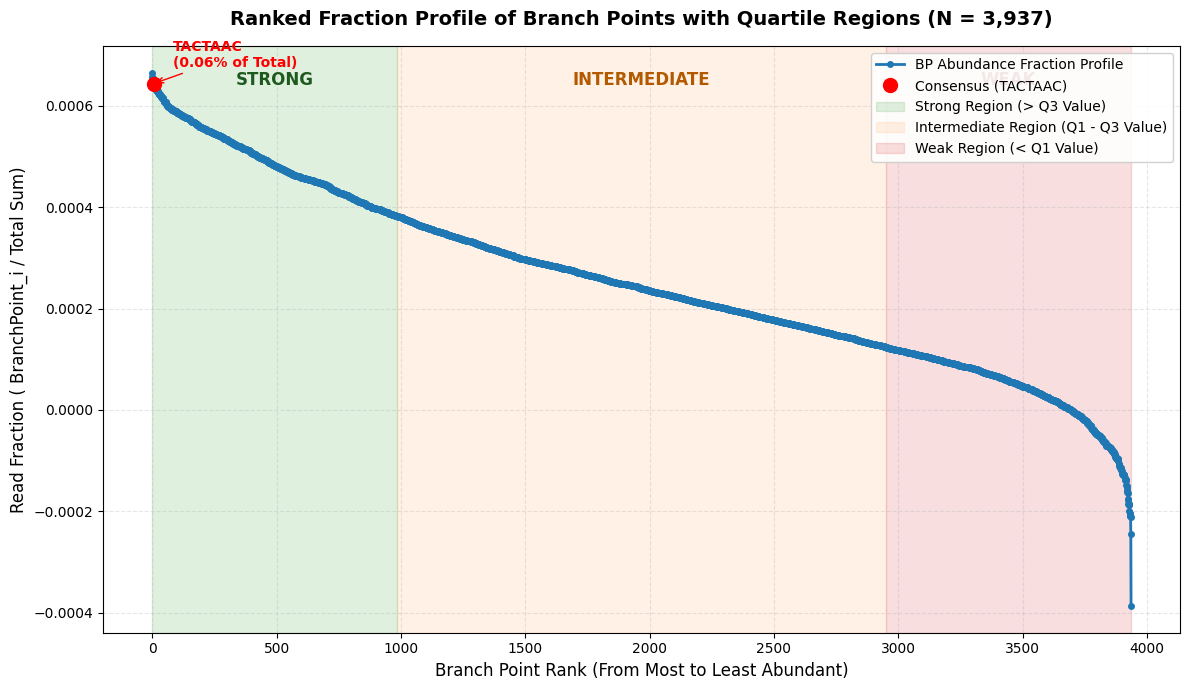

In [20]:

# 1. Group by BP_extracted and compute the mean normalized reads
bp_distribution = dna.groupby('BP_extracted')['norm_reads_Ctrl'].mean()

# Dynamically count the number of unique branch point groups analyzed
num_sequences = len(bp_distribution)

# 2. Calculate the fraction of each BP's reads relative to the total sum of reads
overall_sum = bp_distribution.sum()
bp_fraction = bp_distribution / overall_sum

# 3. Sort the fractions from highest to lowest (Ranking)
bp_fraction_ranked = bp_fraction.sort_values(ascending=False)

# Extract values and categories to map specific indexes
ranked_values = bp_fraction_ranked.values
ranked_categories = bp_fraction_ranked.index.tolist()

# 4. Calculate the 25th (Q1), 50th (Q2/Median), and 75th (Q3) percentiles of the fraction values
q1_val = np.percentile(ranked_values, 25)
q2_val = np.percentile(ranked_values, 50)
q3_val = np.percentile(ranked_values, 75)

# Save the calculated quartile thresholds into a structured dictionary
bp_quartiles = {
    'Q1_25th': q1_val,
    'Q2_50th_Median': q2_val,
    'Q3_75th': q3_val
}

# Print the dynamic sequence count and quartile summary to the console
print(f"Total Unique Categories Evaluated: {num_sequences:,}")
print("---")
print("Calculated Quartiles for Read Fractions relative to the Total Sum:")
print(f"First Quartile  (Q1 - 25th percentile): {bp_quartiles['Q1_25th']:.6f}")
print(f"Second Quartile (Q2 - Median):          {bp_quartiles['Q2_50th_Median']:.6f}")
print(f"Third Quartile  (Q3 - 75th percentile): {bp_quartiles['Q3_75th']:.4f}")
print("---")

# 5. Generate the Plot with Quartile Regions
plt.figure(figsize=(12, 7))

# Plot the main ranked line profile
plt.plot(ranked_values, marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=4, label='BP Abundance Fraction Profile', zorder=3)

# Locate and highlight the consensus target sequence "TACTAAC" if present
target_seq = 'TACTAAC'
if target_seq in ranked_categories:
    target_idx = ranked_categories.index(target_seq)
    target_val = ranked_values[target_idx]
    
    plt.plot(target_idx, target_val, marker='o', color='red', markersize=10, linestyle='None', label=f'Consensus ({target_seq})', zorder=4)
    
    # Calculate percentage for text readability
    target_percentage = target_val * 100
    plt.annotate(
        f'{target_seq}\n({target_percentage:.2f}% of Total)',
        xy=(target_idx, target_val),
        xytext=(target_idx + len(ranked_values)*0.02, target_val + (np.max(ranked_values) * 0.05)),
        color='red',
        weight='bold',
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color='red', lw=1),
        zorder=5
    )

# Map X-coordinates dynamically based on numerical quartile thresholds
# Since ranked_values is in descending order, higher fractions are on the left
x_q3 = np.max(np.where(ranked_values >= bp_quartiles['Q3_75th']))
x_q1 = np.min(np.where(ranked_values <= bp_quartiles['Q1_25th']))
max_x = len(ranked_values) - 1

# Highlight background regions for Strong, Intermediate, and Weak categories
plt.axvspan(0, x_q3, color='#2ca02c', alpha=0.15, label='Strong Region (> Q3 Value)', zorder=1)
plt.axvspan(x_q3, x_q1, color='#ff7f0e', alpha=0.10, label='Intermediate Region (Q1 - Q3 Value)', zorder=1)
plt.axvspan(x_q1, max_x, color='#d62728', alpha=0.15, label='Weak Region (< Q1 Value)', zorder=1)

# Overlay text boundaries near the top boundary of the graph
ymin, ymax = plt.gca().get_ylim()
text_y_position = ymax * 0.93  # Positions labels dynamically in the linear scale area

plt.text(x_q3 / 2, text_y_position, 'STRONG', color='#1e5a1e', fontsize=12, fontweight='bold', ha='center', va='top')
plt.text((x_q3 + x_q1) / 2, text_y_position, 'INTERMEDIATE', color='#b35900', fontsize=12, fontweight='bold', ha='center', va='top')
plt.text((x_q1 + max_x) / 2, text_y_position, 'WEAK', color='#8c1a1a', fontsize=12, fontweight='bold', ha='center', va='top')

# Linear Y-axis modifications (Explicitly removed yscale('log') and mean line)
plt.title(f'Ranked Fraction Profile of Branch Points with Quartile Regions (N = {num_sequences:,})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Branch Point Rank (From Most to Least Abundant)', fontsize=12)
plt.ylabel('Read Fraction ( BranchPoint_i / Total Sum)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3, zorder=2)
plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


In [21]:
res_filtered.groupby("bp_seq")["svm_scr"].mean()
dna.groupby('BP_extracted')['norm_reads_Ctrl'].mean()

BP_extracted
AAAAAAA   -0.034127
AAAAAAC    1.088974
AAAAAAG    0.032150
AAAAAAT    1.050714
AAAACAA    0.960742
             ...   
TTTTGAT    2.970783
TTTTTAA    1.821406
TTTTTAC    2.053582
TTTTTAG    0.372497
TTTTTAT    1.670111
Name: norm_reads_Ctrl, Length: 3937, dtype: float64

# IDEA FONDAMENTALE

Dato che ho due tipi di misura: empirical distribuction and predicted score, voglio andare ad usarli in sinergia per vedere se combaciano. La mia idea fondamentale è di andare a comparare gli score dei Branch Point che ho trovato con SVM finder (1700 dei 4000 iniziali) con la frequezna relativa di normalized reads nella condiozione di controllo senza decoy e con PYT strong (che dovrebbe andare a rappresentare solo l'influenza del branch point sull'assemblaggio e quindi la sua 'forza'). 

L'assunzione di base è che il BP agisca come forza isolata (questo ci permette di vedere la distribuzione empirica) e se è alto nella classe no decoy allora è alto anche nella classe decoy ecc. 

L'idea è di andare a vedere se esiste una correlazione tra le due cose e se esiste usare quella empirica (che comprende anche le altre sequenze )  come base per calcolare i quartili e definire le sequenze strong - intermediate - weack.

- Per fare questo devo andare a prendere solo i BranchPoint condivisi in SVM  e nei dati. 
- Mi porto dietro score medio di questi branchpoint e la frequenza di reads rispetto al totale.
- calcolo la correlazione tra questi due indici per questi 1700 bp.
- plotto con uno scatterplot e una linea in mezzo con r_correlation_coefficient


Se ok 
- allora prendo la distribuzione empirica
- la affetto
-  associo nel df: dna, la sequenza alla sua classificazione (generalizzando per tutte le condizioni)

### Create the shared dataframe 

In [123]:
# 1. Forza l'estrazione e assicurati che sia nel dataframe 'dna'
dna['BP_extracted'] = BP_extractor(dna)

# Sicurezza: Convertiamo esplicitamente le colonne chiave in stringhe o interi per evitare mismatch nel merge
dna['seq_id'] = dna['seq_id'].astype(str)
res_filtered['seq_id_num'] = res_filtered['seq_id_num'].astype(str)

# 2. Esegui il merge completo portando TUTTE le colonne
# Se ci sono colonne con lo stesso nome, forziamo i suffissi '_res' e '_dna'
merged_full = res_filtered.merge(
    dna,
    left_on='seq_id_num',
    right_on='seq_id',
    how='inner',
    suffixes=('_res', '_dna')
)

# 3. Controllo dinamico del nome della colonna per evitare il KeyError
# Se pandas ha aggiunto il suffisso perché esisteva già in res_filtered, usiamo quello corretto
col_target = 'BP_extracted_dna' if 'BP_extracted_dna' in merged_full.columns else 'BP_extracted'

# 4. Creazione della maschera booleana con gestione dei valori mancanti (NaN)
bp_match = merged_full.apply(
    lambda row: pd.notna(row[col_target]) and pd.notna(row['bp_seq']) and str(row[col_target]) in str(row['bp_seq']),
    axis=1
)

# 5. Generazione del dataframe finale filtrato
shared_bp = merged_full[bp_match].copy()

print(f"DataFrame 'shared_bp' creato correttamente!")
print(f"Dimensioni finali: {shared_bp.shape}")


DataFrame 'shared_bp' creato correttamente!
Dimensioni finali: (20826, 45)


In [125]:
shared_bp = shared_bp.loc[:, ['DECOY','ANCHOR', 'svm_scr', 'seq_id_res', 'norm_reads_Ctrl_dna', 'norm_reads_PB1', 'norm_reads_PB2',
       'norm_reads_PB4', 'norm_reads_PB8', 'seq_feature', 'BP_extracted_dna']]

## Select only the No Decoy sequences to compare with the empirical distribuction  (1400 out of 1700 retained)

In [126]:
shared_bp_no_decoy = shared_bp[(shared_bp['DECOY'] == 'Decoy 7')].reset_index(drop=True)

## Use the fraction of reads $(reads(nodecoy.PYTstrong) / sum(reads(nodecoy.PYTstrong)))$

In [127]:
# 1. Calcoliamo la somma totale delle reads nel dataframe per usarla come denominatore globale
total_reads_sum = shared_bp_no_decoy['norm_reads_Ctrl_dna'].sum()

# 2. Raggruppiamo per 'BP_extracted_dna' e applichiamo le rispettive aggregazioni:
#    - Per 'svm_scr' calcoliamo la media (.mean())
#    - Per 'norm_reads_Ctrl_dna' calcoliamo la somma parziale di quel gruppo (.sum())
aggregated = shared_bp_no_decoy.groupby('BP_extracted_dna').agg(
    mean_svm=('svm_scr', 'mean'),
    sum_reads=('norm_reads_Ctrl_dna', 'sum'),
).reset_index()

# 3. Creiamo il DataFrame finale 'stat' con la struttura e i nomi richiesti
stat = pd.DataFrame()
stat['BP_exp'] = aggregated['BP_extracted_dna']
stat['svm_scr'] = aggregated['mean_svm']

# Calcoliamo la frazione dividendo la somma di ogni gruppo per la somma totale globale
stat['read_fraction'] = aggregated['sum_reads'] / total_reads_sum

# Ordiniamo opzionalmente per frazione decrescente (comodo per i plot successivi)
stat = stat.sort_values(by='read_fraction', ascending=False).reset_index(drop=True)

# Verifica rapida del risultato
print(f"DataFrame 'stat' creato con successo! Dimensioni: {stat.shape}")
print(f"Verifica somma delle frazioni (deve essere circa 1.0): {stat['read_fraction'].sum():.4f}")


DataFrame 'stat' creato con successo! Dimensioni: (1414, 3)
Verifica somma delle frazioni (deve essere circa 1.0): 1.0000


# Compute and visualize Spearman and Pearson Correlation Coefficient

Analysis completed using the full dataset.
Total unique Branch Points: 1414
Pearson Correlation (Linear):    r = 0.383 (p = 1.24e-50)
Spearman Correlation (Rank):     rho = 0.552 (p = 1.20e-113)
---


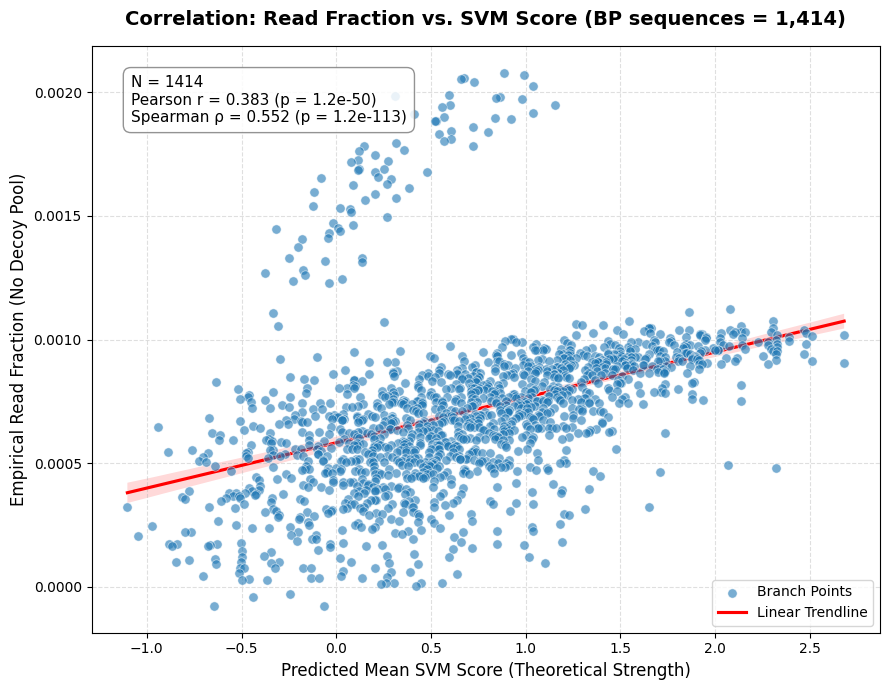

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# =====================================================================
# 1. CORRELATION ANALYSIS (FULL DATASET)
# =====================================================================
# We use the complete dataset 'stat' without filtering out any cluster
stat_full = stat.copy()

# Calculate correlations on the full dataset
r_pearson, p_pearson = stats.pearsonr(stat_full['svm_scr'], stat_full['read_fraction'])
r_spearman, p_spearman = stats.spearmanr(stat_full['svm_scr'], stat_full['read_fraction'])

num_bp_full = len(stat_full)

# Print statistical summary to the console
print(f"Analysis completed using the full dataset.")
print(f"Total unique Branch Points: {num_bp_full}")
print(f"Pearson Correlation (Linear):    r = {r_pearson:.3f} (p = {p_pearson:.2e})")
print(f"Spearman Correlation (Rank):     rho = {r_spearman:.3f} (p = {p_spearman:.2e})")
print("---")

# =====================================================================
# 2. SCATTERPLOT GENERATION (ACADEMIC ENGLISH)
# =====================================================================
plt.figure(figsize=(9, 7))

# Plot all data points
sns.scatterplot(
    data=stat_full, 
    x='svm_scr', 
    y='read_fraction', 
    alpha=0.6, 
    color='#1f77b4', 
    edgecolor='w', 
    s=45,
    label='Branch Points',
    zorder=3
)

# Plot the linear trendline for the full dataset
sns.regplot(
    data=stat_full, 
    x='svm_scr', 
    y='read_fraction', 
    scatter=False, 
    color='red', 
    label='Linear Trendline',
)

# Text box containing statistical metrics
text_box_full = (
    f"N = {num_bp_full}\n"
    f"Pearson r = {r_pearson:.3f} (p = {p_pearson:.1e})\n"
    f"Spearman ρ = {r_spearman:.3f} (p = {p_spearman:.1e})"
)

plt.gca().text(
    0.05, 0.95, text_box_full, 
    transform=plt.gca().transAxes, 
    fontsize=11, 
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray')
)

# Titles and axis labels
plt.title(f'Correlation: Read Fraction vs. SVM Score (BP sequences = {num_bp_full:,})', fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Predicted Mean SVM Score (Theoretical Strength)', fontsize=12)
plt.ylabel('Empirical Read Fraction (No Decoy Pool)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4, zorder=1)
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


# Does it holds for all the conditions? Generalization - a qualitative approach

Dato che andro a prendere alla fine solo relativamente alla condizione di controllo potrebbe essere interessante andare a vedere se la correlazione viene mantenuta tra i vari decoy. -> risponde alla domanda se posso generalizzare questa misura anche agli altri decoy

Posso andare anche a vedere se si mantiene con il farmaco. -> risponde alla domanda se posso generalizzare anche alle altre condizioni

# Other decoy generalization

[Decoy 7] Total Raw Unique Branch Points: 1414
[Decoy 7] Pearson r  = 0.383 (p = 1.24e-50)
[Decoy 7] Spearman rho = 0.552 (p = 1.20e-113)
--------------------------------------------------
[Decoy 5] Total Raw Unique Branch Points: 1430
[Decoy 5] Pearson r  = 0.408 (p = 1.62e-58)
[Decoy 5] Spearman rho = 0.560 (p = 1.33e-118)
--------------------------------------------------
[Decoy 3] Total Raw Unique Branch Points: 1437
[Decoy 3] Pearson r  = 0.399 (p = 3.56e-56)
[Decoy 3] Spearman rho = 0.558 (p = 2.10e-118)
--------------------------------------------------
[Decoy 1] Total Raw Unique Branch Points: 1428
[Decoy 1] Pearson r  = 0.382 (p = 6.29e-51)
[Decoy 1] Spearman rho = 0.554 (p = 1.55e-115)
--------------------------------------------------


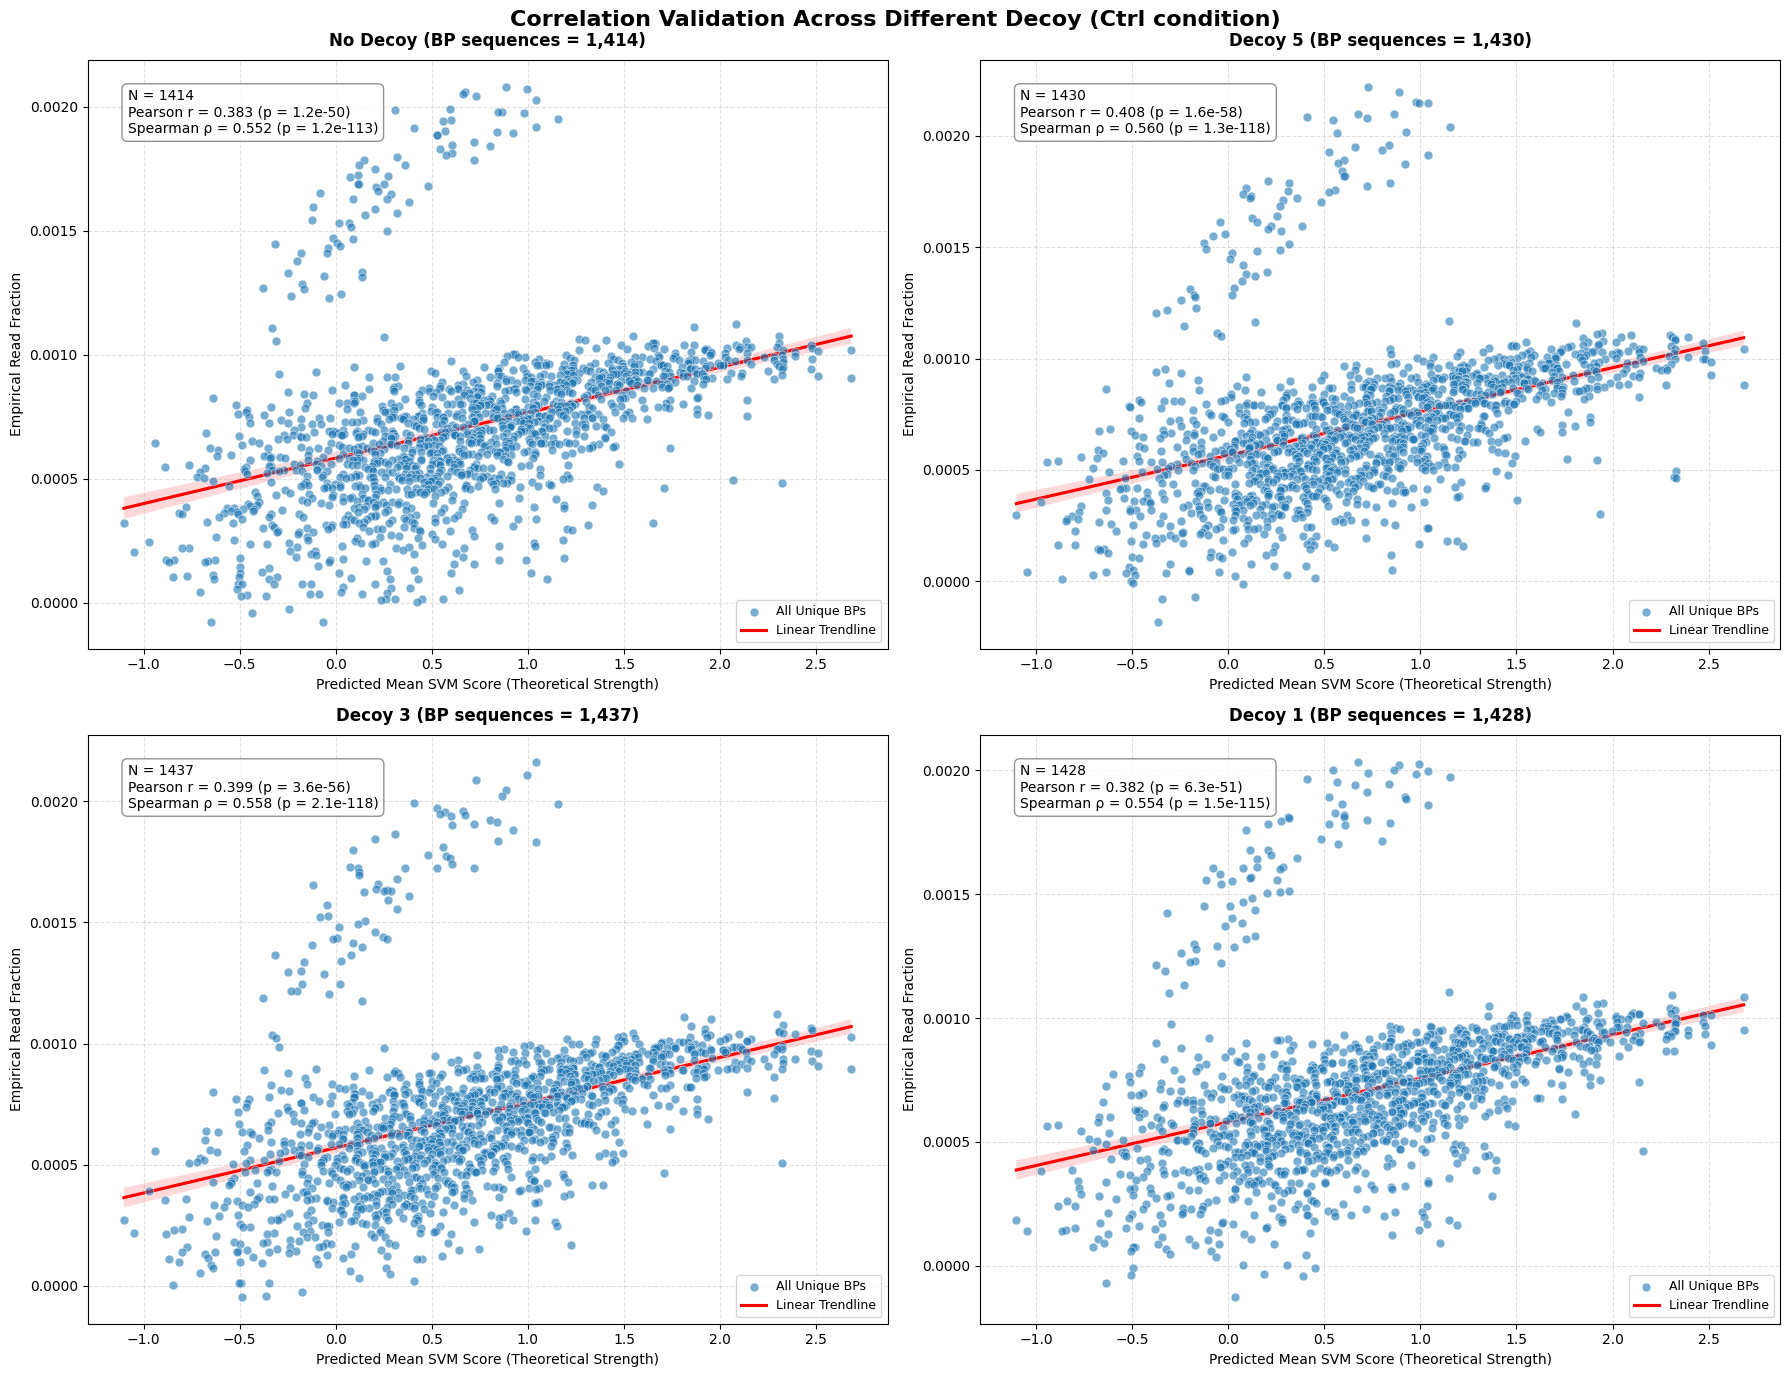

In [195]:


# List of Decoys to analyze in sequence (No filtering will be applied)
decoy_list = ['Decoy 7', 'Decoy 5', 'Decoy 3', 'Decoy 1']

# Initialize a 2x2 grid for subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()  # Flatten the 2x2 matrix into a list for easy iteration

for i, decoy in enumerate(decoy_list):
    ax = axes[i]
    
    # 1. Filter the master dataframe for the specific Decoy condition
    df_decoy_specific = shared_bp[shared_bp['DECOY'] == decoy].reset_index(drop=True)
    
    if len(df_decoy_specific) == 0:
        print(f"Warning: No data found for {decoy}. Skipping plot.")
        continue
        
    # 2. Dynamic Column Detection to eliminate KeyErrors permanently
    # Find the column that matches or contains 'svm_scr' or 'BP_extracted'
    svm_col = [c for c in df_decoy_specific.columns if 'svm_scr' in c][0]
    bp_col = [c for c in df_decoy_specific.columns if 'BP_extracted' in c][0]
    reads_col = [c for c in df_decoy_specific.columns if 'norm_reads_Ctrl' in c][0]
    
    # 3. Compute the local denominator for relative frequencies
    total_reads_sum = df_decoy_specific[reads_col].sum()
    
    # Aggregate metrics for each unique Branch Point (Dynamic Column Mapping)
    stat_raw = df_decoy_specific.groupby(bp_col).agg(
        mean_svm=(svm_col, 'mean'),
        sum_reads=(reads_col, 'sum'),
    ).reset_index()
    
    # Rename columns to standardized terms for the plotting environment
    stat_raw.columns = ['BP_exp', 'svm_scr', 'sum_reads']
    
    # Calculate the empirical fraction based on the full raw population
    stat_raw['read_fraction'] = stat_raw['sum_reads'] / total_reads_sum
    stat_raw = stat_raw.sort_values(by='read_fraction', ascending=False).reset_index(drop=True)
    
    # =====================================================================
    # CORRELATION COEFFICIENTS CALCULATION (RAW DATA)
    # =====================================================================
    r_pearson, p_pearson = stats.pearsonr(stat_raw['svm_scr'], stat_raw['read_fraction'])
    r_spearman, p_spearman = stats.spearmanr(stat_raw['svm_scr'], stat_raw['read_fraction'])
    num_bp_total = len(stat_raw)
    
    # Print console logs for tracking
    print(f"[{decoy}] Total Raw Unique Branch Points: {num_bp_total}")
    print(f"[{decoy}] Pearson r  = {r_pearson:.3f} (p = {p_pearson:.2e})")
    print(f"[{decoy}] Spearman rho = {r_spearman:.3f} (p = {p_spearman:.2e})")
    print("-" * 50)
    
    # =====================================================================
    # SUBPLOT GENERATION (ENGLISH B2)
    # =====================================================================
    # Scatter plot containing the complete raw population
    sns.scatterplot(
        data=stat_raw, 
        x='svm_scr', 
        y='read_fraction', 
        alpha=0.6, 
        color='#1f77b4', 
        edgecolor='w', 
        s=40,
        label='All Unique BPs',
        ax=ax,
        zorder=3
    )
    
    # Linear trendline tracking the raw dataset distribution
    sns.regplot(
        data=stat_raw, 
        x='svm_scr', 
        y='read_fraction', 
        scatter=False, 
        color='red', 
        label='Linear Trendline',
        ax=ax,    )
    
    # Informative statistics text box (Academic English)
    text_box_content = (
        f"N = {num_bp_total}\n"
        f"Pearson r = {r_pearson:.3f} (p = {p_pearson:.1e})\n"
        f"Spearman ρ = {r_spearman:.3f} (p = {p_spearman:.1e})"
    )
    
    ax.text(
        0.05, 0.95, text_box_content, 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray'),
        zorder=5
    )
    
    # Dynamic titles reflecting total sequence counts
    title_label = "No Decoy" if decoy == 'Decoy 7' else f"{decoy}"
    ax.set_title(f"{title_label} (BP sequences = {num_bp_total:,})", fontsize=12, fontweight='bold', pad=10)
    
    # Layout configuration for each plot panel
    ax.set_xlabel('Predicted Mean SVM Score (Theoretical Strength)', fontsize=10)
    ax.set_ylabel('Empirical Read Fraction', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    ax.legend(loc='lower right', fontsize=9)

# Adjust spacing between subplots to ensure no title clipping
plt.suptitle('Correlation Validation Across Different Decoy (Ctrl condition)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# Other condition (drug) generalization

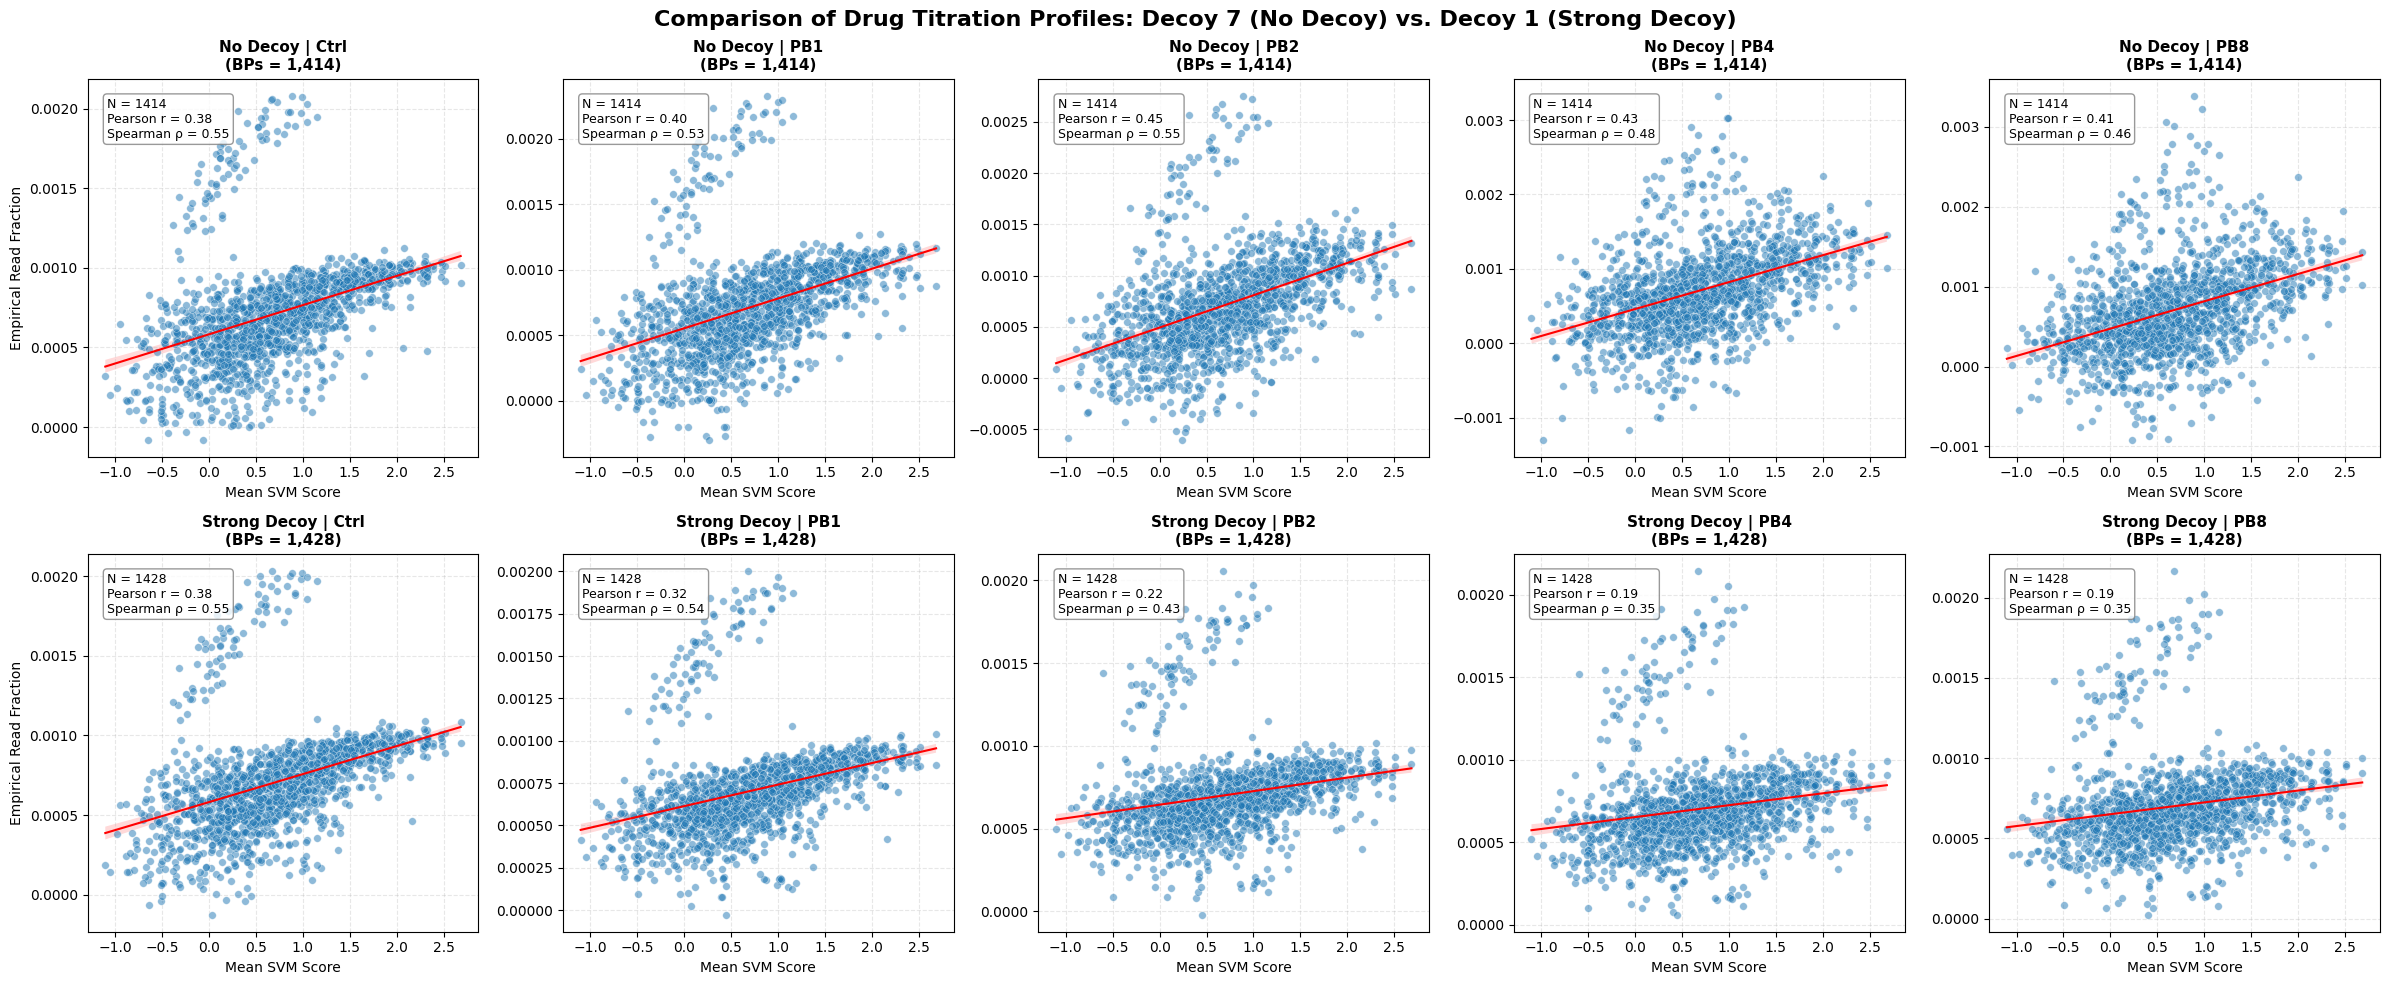

In [ ]:


# 1. Definiamo le colonne di farmaco da analizzare in sequenza cronologica
drug_columns = ['norm_reads_Ctrl_dna', 'norm_reads_PB1', 'norm_reads_PB2', 'norm_reads_PB4', 'norm_reads_PB8']

# Definiamo i due decoy da confrontare (riga 1 e riga 2)
decoys_to_plot = ['Decoy 7', 'Decoy 1']

# Inizializziamo una griglia di 2 righe e 5 colonne (10 subplots totali)
fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharey=False)

for row_idx, decoy in enumerate(decoys_to_plot):
    # Filtriamo il pool specifico per il decoy di questa riga
    df_decoy_specific = shared_bp[shared_bp['DECOY'] == decoy].reset_index(drop=True)
    
    for col_idx, col in enumerate(drug_columns):
        # Selezioniamo il singolo riquadro (ax) corrispondente alla cella della matrice
        ax = axes[row_idx, col_idx]
        
        # 2. Calcolo del denominatore specifico per il pool e la colonna corrente
        total_reads_condition = df_decoy_specific[col].sum()
        
        if total_reads_condition == 0:
            print(f"Warning: Zero reads found for {decoy} in column {col}. Skipping subplot.")
            continue
        
        # 3. Aggregazione per Branch Point unico (senza alcun filtro geometrico degli outlier)
        stat_drug = df_decoy_specific.groupby('BP_extracted_dna').agg(
            mean_svm=('svm_scr', 'mean'),
            sum_reads=(col, 'sum')
        ).reset_index()
        
        # Calcolo della frazione relativa locale per questa specifica condizione
        stat_drug['read_fraction'] = stat_drug['sum_reads'] / total_reads_condition
        
        # 4. Calcolo dei coefficienti di correlazione grezzi
        r_pearson, p_pearson = stats.pearsonr(stat_drug['mean_svm'], stat_drug['read_fraction'])
        r_spearman, p_spearman = stats.spearmanr(stat_drug['mean_svm'], stat_drug['read_fraction'])
        num_bp = len(stat_drug)
        
        # 5. Generazione del grafico (Scatter Plot + Linea di tendenza corretta)
        sns.scatterplot(
            data=stat_drug, 
            x='mean_svm', 
            y='read_fraction', 
            alpha=0.5, 
            color='#1f77b4', 
            edgecolor='w', 
            s=30,
            ax=ax,
            zorder=3
        )
        
        # Le proprietà grafiche della linea sono passate in modo sicuro tramite line_kws
        sns.regplot(
            data=stat_drug, 
            x='mean_svm', 
            y='read_fraction', 
            scatter=False, 
            ax=ax,
            line_kws=dict(color='red', linewidth=1.5, zorder=4)
        )
        
        # Riquadro informativo con le statistiche (English B2)
        text_box_content = (
            f"N = {num_bp}\n"
            f"Pearson r = {r_pearson:.2f}\n"
            f"Spearman ρ = {r_spearman:.2f}"
        )
        
        ax.text(
            0.05, 0.95, text_box_content, 
            transform=ax.transAxes, 
            fontsize=9, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
            zorder=5
        )
        
        # Configurazione del titolo dinamico per ogni cella della griglia
        condition_label = col.replace('norm_reads_', '').replace('_dna', '')
        row_label = "No Decoy" if decoy == 'Decoy 7' else "Strong Decoy"
        ax.set_title(f"{row_label} | {condition_label}\n(BPs = {num_bp:,})", fontsize=11, fontweight='bold')
        
        ax.set_xlabel('Mean SVM Score', fontsize=10)
        
        # Mostriamo l'etichetta dell'asse Y solo sulla prima colonna per mantenere pulito il layout
        if col_idx == 0:
            ax.set_ylabel('Empirical Read Fraction', fontsize=10)
        else:
            ax.set_ylabel('')
            
        ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

# Titolo principale dell'intera figura
plt.suptitle('Comparison of Drug Titration Profiles: Decoy 7 (No Decoy) vs. Decoy 1 (Strong Decoy)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# Interpretation: seems a good approximation to use empirical distribuction (No Decoy + pyt sTRONG) as reference for BP Strength

In [146]:
df = dna.loc[:, ['seq_id','seq_feature', 'norm_reads_Ctrl', 'BP_extracted', 'DECOY']].copy()
df_nodec = df[df['DECOY'] == 'Decoy 7']

# Attenction: In our analysis we're missing the analysis of  7.52% of the BP

In [ ]:
missing_fraction = (data_raw['BP_extracted'].nunique()  - df_nodec['BP_extracted'].nunique()  ) / data_raw['BP_extracted'].nunique()
missing_perc = missing_fraction * 100
print(f"Be careful!!!! Missing the  analiysis for {missing_perc:.2f}% of the BPs")

Be careful!!!! Missing the classification prediction for 7.52% of the BPs


<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
C:\Users\marco\AppData\Local\Temp\ipykernel_17612\3514492791.py:92: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Average Read Fraction ($\mathregular{{BranchPoint_i}}$ / Total Sum)', fontsize=12)


Total Unique Categories Evaluated: 3,787
---
Calculated Quartiles for Read Fractions relative to the Total Sum:
First Quartile  (Q1 - 25th percentile): 0.000153
Second Quartile (Q2 - Median):          0.000259
Third Quartile  (Q3 - 75th percentile): 0.000378
---


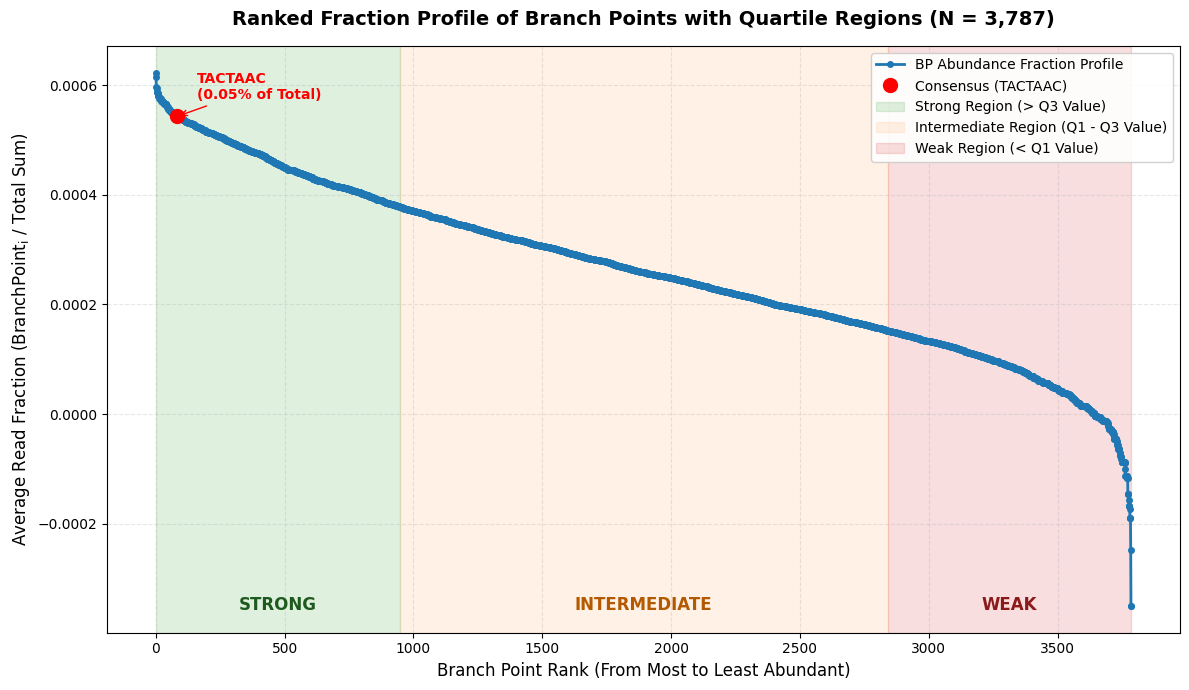

In [ ]:

# 1. Group by BP_extracted and compute the mean normalized reads from df_nodec
bp_distribution = df_nodec.groupby('BP_extracted')['norm_reads_Ctrl'].mean()

# Dynamically count the number of unique branch point groups analyzed
num_sequences = len(bp_distribution)

# 2. Calculate the fraction of each BP's reads relative to the total sum of reads
overall_sum = bp_distribution.sum()
bp_fraction = bp_distribution / overall_sum

# 3. Sort the fractions from highest to lowest (Ranking)
bp_fraction_ranked = bp_fraction.sort_values(ascending=False)

# Extract values and categories to map specific indexes
ranked_values = bp_fraction_ranked.values
ranked_categories = bp_fraction_ranked.index.tolist()

# 4. Calculate the 25th (Q1), 50th (Q2/Median), and 75th (Q3) percentiles of the fraction values
q1_val = np.percentile(ranked_values, 25)
q2_val = np.percentile(ranked_values, 50)
q3_val = np.percentile(ranked_values, 75)

# Save the calculated quartile thresholds into a structured dictionary
# These are the final values you will use to categorize your master dataset
bp_quartiles = {
    'Q1_25th': q1_val,
    'Q2_50th_Median': q2_val,
    'Q3_75th': q3_val
}

# Print the dynamic sequence count and quartile summary to the console
print(f"Total Unique Categories Evaluated: {num_sequences:,}")
print("---")
print("Calculated Quartiles for Read Fractions relative to the Total Sum:")
print(f"First Quartile  (Q1 - 25th percentile): {bp_quartiles['Q1_25th']:.6f}")
print(f"Second Quartile (Q2 - Median):          {bp_quartiles['Q2_50th_Median']:.6f}")
print(f"Third Quartile  (Q3 - 75th percentile): {bp_quartiles['Q3_75th']:.6f}")
print("---")
# 5. Generate the Plot with Quartile Regions
plt.figure(figsize=(12, 7))

# Plot the main ranked line profile
plt.plot(ranked_values, marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=4, label='BP Abundance Fraction Profile', zorder=3)

# Locate and highlight the consensus target sequence "TACTAAC" if present
target_seq = 'TACTAAC'
if target_seq in ranked_categories:
    target_idx = ranked_categories.index(target_seq)
    target_val = ranked_values[target_idx]
    
    plt.plot(target_idx, target_val, marker='o', color='red', markersize=10, linestyle='None', label=f'Consensus ({target_seq})', zorder=4)
    
    # Calculate percentage for text readability
    target_percentage = target_val * 100
    plt.annotate(
        f'{target_seq}\n({target_percentage:.2f}% of Total)',
        xy=(target_idx, target_val),
        xytext=(target_idx + len(ranked_values)*0.02, target_val + (np.max(ranked_values) * 0.05)),
        color='red',
        weight='bold',
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color='red', lw=1),
        zorder=5
    )

# Map X-coordinates dynamically based on numerical quartile thresholds
x_q3 = np.max(np.where(ranked_values >= bp_quartiles['Q3_75th']))
x_q1 = np.min(np.where(ranked_values <= bp_quartiles['Q1_25th']))
max_x = len(ranked_values) - 1

# Highlight background regions for Strong, Intermediate, and Weak categories
plt.axvspan(0, x_q3, color='#2ca02c', alpha=0.15, label='Strong Region (> Q3 Value)', zorder=1)
plt.axvspan(x_q3, x_q1, color='#ff7f0e', alpha=0.10, label='Intermediate Region (Q1 - Q3 Value)', zorder=1)
plt.axvspan(x_q1, max_x, color='#d62728', alpha=0.15, label='Weak Region (< Q1 Value)', zorder=1)

# MODIFICATO: Calcolo della posizione Y in basso per i testi delle zone
ymin, ymax = plt.gca().get_ylim()
text_y_position = ymin + (ymax * 0.05)  # Posiziona il testo al 5% dell'altezza partendo dal basso

# Inserimento dei testi in basso (cambiato va='bottom' per un allineamento perfetto)
plt.text(x_q3 / 2, text_y_position, 'STRONG', color='#1e5a1e', fontsize=12, fontweight='bold', ha='center', va='bottom')
plt.text((x_q3 + x_q1) / 2, text_y_position, 'INTERMEDIATE', color='#b35900', fontsize=12, fontweight='bold', ha='center', va='bottom')
plt.text((x_q1 + max_x) / 2, text_y_position, 'WEAK', color='#8c1a1a', fontsize=12, fontweight='bold', ha='center', va='bottom')

# Linear Y-axis modifications
plt.title(f'Ranked Fraction Profile of Branch Points with Quartile Regions (N = {num_sequences:,})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Branch Point Rank (From Most to Least Abundant)', fontsize=12)
plt.ylabel('Average Read Fraction ($\mathregular{{BranchPoint_i}}$ / Total Sum)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3, zorder=2)

# Spostiamo la legenda in alto a destra per evitare che copra le scritte in basso
plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


# Compute the quartile over absolute concentration and than assig the class to the BPs

In [176]:
# 1. Group by BP_extracted and compute the mean normalized reads from df_nodec
bp_distribution = df_nodec.groupby('BP_extracted')['norm_reads_Ctrl'].mean()


# 3. Sort the fractions from highest to lowest (Ranking)
bp_ranked = bp_distribution.sort_values(ascending=False)

# Extract values and categories to map specific indexes
ranked_values = bp_ranked.values
ranked_categories = bp_ranked.index.tolist()

# 4. Calculate the 25th (Q1), 50th (Q2/Median), and 75th (Q3) percentiles of the fraction values
q1_val = np.percentile(ranked_values, 25)
q2_val = np.percentile(ranked_values, 50)
q3_val = np.percentile(ranked_values, 75)
print(q1_val, q3_val)

1.0384140530148365 2.572937035197405


In [ ]:
import numpy as np

# 1. Calcoliamo i punti di taglio basati sulle POSIZIONI (Rank) della classifica dei BP
# Ricorda che ranked_categories contiene i nomi dei BP ordinati dal più forte al più debole
total_unique_bps = len(ranked_categories)

cut_strong = int(total_unique_bps * 0.25)      # Top 25% dei BP
cut_intermediate = int(total_unique_bps * 0.75)  # Dal 25% al 75% dei BP

# 2. Isolate le liste con i nomi dei Branch Point appartenenti a ciascuna fascia
strong_bp_names = set(ranked_categories[:cut_strong])
intermediate_bp_names = set(ranked_categories[cut_strong:cut_intermediate])
weak_bp_names = set(ranked_categories[cut_intermediate:])

# 3. Definiamo le condizioni verificando se il BP della riga appartiene a una delle tre liste
# Nota: Sostituisci 'BP_extracted' con il nome esatto della colonna dei BP in data_filtered se diverso
conditions = [
    (dna['BP_extracted'].isin(strong_bp_names)),
    (dna['BP_extracted'].isin(intermediate_bp_names)),
    (dna['BP_extracted'].isin(weak_bp_names))
]

# 4. Definiamo le etichette corrispondenti
choices = ['Strong', 'Intermediate', 'Weak']

# 5. Applichiamo la classificazione in modo vettorizzato
dna['BP_class'] = np.select(conditions, choices, default='Unknown')

# =====================================================================
# VERIFICA DEL RISULTATO 
# =====================================================================
print("Sequence classification corrected based on Rank thresholds.")
print("---")
print(f"Unique Branch Points breakdown: Strong={len(strong_bp_names)}, Intermediate={len(intermediate_bp_names)}, Weak={len(weak_bp_names)}")
print("---")
print("New distribution of the 'BP_class' column across all rows:")
print(dna['BP_class'].value_counts())
print("\nNew percentage distribution across all rows:")
print(dna['BP_class'].value_counts(normalize=True) * 100)


Sequence classification corrected based on Rank thresholds.
---
Unique Branch Points breakdown: Strong=946, Intermediate=1894, Weak=947
---
New distribution of the 'BP_class' column across all rows:
BP_class
Intermediate    26243
Strong          13126
Weak            12767
Unknown           671
Name: count, dtype: int64

New percentage distribution across all rows:
BP_class
Intermediate    49.696063
Strong          24.856553
Weak            24.176719
Unknown          1.270665
Name: proportion, dtype: float64


### Classification Check

In [196]:
# =====================================================================
# MINI-CHECK: VERIFICA DELLA GERARCHIA DELLE READS (Strong > Intermediate > Weak)
# =====================================================================

# 1. Identifichiamo tutte le colonne che iniziano con "norm_reads_"
read_cols = [col for col in dna.columns if col.startswith('norm_reads_')]

print("--- RUNNING HIERARCHY CHECK ---")
all_conditions_passed = True

# 2. Iteriamo su ciascuna colonna di reads per verificare la gerarchia
for col in read_cols:
    # Calcoliamo la media per ogni gruppo (escludendo eventuali 'Unknown')
    group_means = dna[dna['BP_class'] != 'Unknown'].groupby('BP_class')[col].mean()
    
    # Estraiamo i valori medi per ciascuna categoria
    mean_strong = group_means.get('Strong', 0)
    mean_interm = group_means.get('Intermediate', 0)
    mean_weak   = group_means.get('Weak', 0)
    
    # Condizione logica: Strong > Intermediate E Intermediate > Weak
    condition_passed = (mean_strong > mean_interm) and (mean_interm > mean_weak)
    
    status = "PASSED ✅" if condition_passed else "FAILED ❌"
    if not condition_passed:
        all_conditions_passed = False
        
    print(f"[{status}] Condition: {col}")
    print(f"          Means -> Strong: {mean_strong:.4f} | Intermediate: {mean_interm:.4f} | Weak: {mean_weak:.4f}\n")

print("--------------------------------")
if all_conditions_passed:
    print("SUCCESS: The hierarchy (Strong > Intermediate > Weak) holds true for ALL read conditions!")
else:
    print("WARNING: One or more conditions do not follow the expected hierarchy.")


--- RUNNING HIERARCHY CHECK ---
[PASSED ✅] Condition: norm_reads_Ctrl
          Means -> Strong: 3.0034 | Intermediate: 1.5392 | Weak: 0.4143

[PASSED ✅] Condition: norm_reads_PB1
          Means -> Strong: 2.5813 | Intermediate: 1.3375 | Weak: 0.4993

[PASSED ✅] Condition: norm_reads_PB2
          Means -> Strong: 1.7184 | Intermediate: 1.1376 | Weak: 0.6424

[PASSED ✅] Condition: norm_reads_PB4
          Means -> Strong: 1.2778 | Intermediate: 1.0461 | Weak: 0.6421

[PASSED ✅] Condition: norm_reads_PB8
          Means -> Strong: 1.2537 | Intermediate: 1.0503 | Weak: 0.6612

--------------------------------
SUCCESS: The hierarchy (Strong > Intermediate > Weak) holds true for ALL read conditions!


In [199]:
data_filtered['BP_class'].unique()

<StringArray>
['Weak', 'Intermediate', 'Strong']
Length: 3, dtype: str